## Feature Engineering

For feature engineering, we tried to clean the data and turn some of the columns into values that would make more sense for the models. We removed the `Id` column because it is just a row number and should not really help with predicting `SalePrice`. For `Alley`, instead of keeping the original column with a lot of missing values, we made a new column called `Has_Alley`. This just says whether the house has alley access or not.

We also filled in missing values depending on what the column was supposed to mean. For example, we used the median for `LotFrontage` because it is a numeric column and the median is a safe value to use when there are outliers. For `MasVnrArea`, we filled missing values with 0 because if there is no masonry veneer, then the area should basically be 0. For columns about things like basement, garage, fireplace, pool, fence, and other extra features, we filled the missing values with `None`, since missing usually means the house does not have that thing.

Some categorical columns had a clear order, so we changed them into numbers. For example, quality ratings like `Ex`, `Gd`, `TA`, `Fa`, and `Po` were changed into scores. We did this because these labels are not random categories; they go from better to worse. We also made a `HasBsmt` column to show if the house has a basement. Other columns like `LandSlope`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2`, `CentralAir`, `Electrical`, `Functional`, `GarageFinish`, and `Fence` were also mapped to numbers because their categories had some kind of ranking or meaning.

For the columns where there was no obvious order, we used one-hot encoding with `pd.get_dummies()`. This was used for columns like zoning, neighborhood, house style, roof type, exterior type, foundation, heating, garage type, sale type, and sale condition. We also dropped `Utilities` because almost all of the values were the same, so it probably would not help the model much.

At the end, we created a few new columns from the existing ones. `TotalBathrooms` adds together the full and half bathrooms, including the basement bathrooms. `Age` tells how old the house was when it was sold, and `RemodAge` tells how many years it had been since the house was remodeled. We also made `TotalSF`, which combines basement area, first floor area, second floor area, wood deck area, and open porch area. The idea was that total space might be more useful than looking at all of those area columns separately.

In [103]:
import pandas as pd

TRAIN_PATH = "https://raw.githubusercontent.com/dana-fatemeh/Final-ML-Project/main/Data/train.csv"

data = pd.read_csv(TRAIN_PATH)
print(data.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [ ]:
import pandas as pd
import numpy as np
def feature_engineer(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()

    if "Id" in data.columns:
        data = data.drop(columns=["Id"])

    data["Has_Alley"] = data["Alley"].notna().astype(int)
    data = data.drop(columns=["Alley"])

    lotshape_map = {
        "Reg": 0,
        "IR1": 1,
        "IR2": 2,
        "IR3": 3,
    }
    data["LotShape"] = data["LotShape"].map(lotshape_map)

    # data["LotFrontage"] = data["LotFrontage"].fillna(data["LotFrontage"].median())
    data["LotFrontage"] = data["LotFrontage"].fillna(0)

    data["MasVnrArea"] = data["MasVnrArea"].fillna(0)

    none_cols = [
        "MasVnrType",
        "BsmtQual",
        "BsmtCond",
        "BsmtExposure",
        "BsmtFinType1",
        "BsmtFinType2",
        "FireplaceQu",
        "PoolQC",
        "Fence",
        "MiscFeature",
        "GarageType",
        "GarageQual",
        "GarageCond",
        # "GarageYrBlt",
        # "Electrical",
    ]

    for col in none_cols:
        data[col] = data[col].fillna("None")
        # data[col] = data[col].fillna(0)

        # data[col] = data[col].fillna(-1)


    data["GarageYrBlt"] = data["GarageYrBlt"].fillna(0)
    data["Electrical"] = data["Electrical"].fillna(0)

    qual_rate = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "None": 0}
    ord_cols = [
        "ExterQual",
        "ExterCond",
        "BsmtQual",
        "BsmtCond",
        "HeatingQC",
        "KitchenQual",
        "FireplaceQu",
        "GarageQual",
        "GarageCond",
        "PoolQC",
    ]
    data["HasBsmt"] = (data["BsmtQual"] != "None").astype(int)
    for col in ord_cols:
        data[col + "_ord"] = data[col].map(qual_rate)
        data = data.drop(columns=[col])

    data = pd.get_dummies(data, columns=["LandContour"], drop_first=False, dtype=int)

    data["LandSlope"] = data["LandSlope"].map({"Gtl": 1, "Mod": 2, "Sev": 5})

    data["BsmtExposure"] = data["BsmtExposure"].map({"Gd": 10, "Av": 6, "Mn": 3, "No": 1, "None": 0})
    data["BsmtFinType1"] = data["BsmtFinType1"].map(
        {"GLQ": 10, "ALQ": 7, "BLQ": 3, "Rec": 5, "LwQ": 2, "Unf": 1, "None": 0}
    )
    data["BsmtFinType2"] = data["BsmtFinType2"].map(
        {"GLQ": 10, "ALQ": 7, "BLQ": 3, "Rec": 5, "LwQ": 2, "Unf": 1, "None": 0}
    )
    data["CentralAir"] = data["CentralAir"].map({"Y": 1, "N": 0})
    data["Electrical"] = data["Electrical"].map({"SBrkr": 10, "FuseA": 7, "FuseF": 3, "FuseP": 1, "Mix": 5})

    data["Functional"] = data["Functional"].map(
        {"Typ": 10, "Min1": 9, "Min2": 8, "Mod": 5, "Maj1": 3, "Maj2": 2, "Sev": 1, "Sal": 0}
    )
    data["GarageFinish"] = data["GarageFinish"].map({"Fin": 5, "RFn": 2, "Unf": 1, "None": 0})
    data["Fence"] = data["Fence"].map({"GdPrv": 5, "MnPrv": 3, "GdWo": 2, "MnWw": 1, "None": 0})

    data = data.drop(columns=["Utilities"])

    categorical_cols = [
        "MSZoning",
        "Street",
        "LotConfig",
        "Neighborhood",
        "Condition1",
        "Condition2",
        "BldgType",
        "HouseStyle",
        "RoofStyle",
        "RoofMatl",
        "Exterior1st",
        "Exterior2nd",
        "MasVnrType",
        "Foundation",
        "Heating",
        "GarageType",
        "PavedDrive",
        "MiscFeature",
        "SaleType",
        "SaleCondition",
        "MSSubClass",
    ]

    data = pd.get_dummies(data, columns=[col for col in categorical_cols], dtype=int)

    data["TotalBathrooms"] = (
        data["FullBath"] + 0.5 * data["HalfBath"] + data["BsmtFullBath"] + 0.5 * data["BsmtHalfBath"]
    )

    data["YearRemodAdd"] = data["YearRemodAdd"].astype(int)
    data["YearBuilt"] = data["YearBuilt"].astype(int)
    data["YrSold"] = data["YrSold"].astype(int)
    data["Age"] = data["YrSold"] - data["YearBuilt"]
    data["RemodAge"] = data["YrSold"] - data["YearRemodAdd"]

    data["TotalSF"] = data["TotalBsmtSF"] + data["1stFlrSF"] + data["2ndFlrSF"]

    data["TotalPorchSF"] = (
        data["OpenPorchSF"]
        + data["EnclosedPorch"]
        + data["3SsnPorch"]
        + data["ScreenPorch"]
        + data["WoodDeckSF"]
    )

    data["QualSF"] = data["OverallQual"] * data["TotalSF"]
    data["TotalQuality"] = data["OverallQual"] + data["OverallCond"]

    data["HasGarage"] = (data["GarageArea"] > 0).astype(int)
    data["HasFireplace"] = (data["Fireplaces"] > 0).astype(int)
    data["HasPool"] = (data["PoolArea"] > 0).astype(int)

    data["LogLotArea"] = np.log(data["LotArea"])
    data["LogGrLivArea"] = np.log(data["GrLivArea"])
    data["LogTotalSF"] = np.log(data["TotalSF"])


    # data["TotalSF"] = (
    #     data["TotalBsmtSF"]
    #     + data["1stFlrSF"]
    #     + data["2ndFlrSF"]
    #     + data["WoodDeckSF"]
    #     + data["OpenPorchSF"]
    # )

    return data

In [105]:
data = pd.read_csv(TRAIN_PATH)
data = feature_engineer(data)
data.head()

,LotFrontage,LotArea,LotShape,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtExposure,...,TotalSF,TotalPorchSF,QualSF,TotalQuality,HasGarage,HasFireplace,HasPool,LogLotArea,LogGrLivArea,LogTotalSF
0,65.0,8450,0,1,7,5,2003,2003,196.0,1,...,2566,61,17962,12,1,0,0,9.041922,7.444249,7.850104
1,80.0,9600,0,1,6,8,1976,1976,0.0,10,...,2524,298,15144,14,1,1,0,9.169518,7.140453,7.833600
2,68.0,11250,1,1,7,5,2001,2002,162.0,3,...,2706,42,18942,12,1,1,0,9.328123,7.487734,7.903227
3,60.0,9550,1,1,7,5,1915,1970,0.0,1,...,2473,307,17311,12,1,1,0,9.164296,7.448334,7.813187
4,84.0,14260,1,1,8,5,2000,2000,350.0,6,...,3343,276,26744,13,1,1,0,9.565214,7.695303,8.114624


In [106]:
print(len(data))

1460


In [107]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 248 entries, LotFrontage to LogTotalSF
dtypes: float64(9), int64(239)
memory usage: 2.8 MB


In [108]:
data.describe()


,LotFrontage,LotArea,LotShape,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtExposure,...,TotalSF,TotalPorchSF,QualSF,TotalQuality,HasGarage,HasFireplace,HasPool,LogLotArea,LogGrLivArea,LogTotalSF
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,57.623288,10516.828082,0.366438,1.080137,6.099315,5.575342,1971.267808,1984.865753,103.117123,2.713014,...,2567.048630,181.329452,16416.028767,11.674658,0.944521,0.527397,0.004795,9.110838,7.267774,7.802455
std,34.664304,9981.264932,0.481996,0.425074,1.382997,1.112799,30.202904,20.645407,180.731373,2.937404,...,821.714421,156.656097,8665.496074,1.693527,0.228992,0.499420,0.069100,0.517448,0.333550,0.313564
min,0.000000,1300.000000,0.000000,1.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,334.000000,0.000000,334.000000,2.000000,0.000000,0.000000,0.000000,7.170120,5.811141,5.811141
25%,42.000000,7553.500000,0.000000,1.000000,5.000000,5.000000,1954.000000,1967.000000,0.000000,1.000000,...,2009.500000,45.000000,10425.000000,11.000000,1.000000,0.000000,0.000000,8.929766,7.029530,7.605641
50%,63.000000,9478.500000,0.000000,1.000000,6.000000,5.000000,1973.000000,1994.000000,0.000000,1.000000,...,2474.000000,164.000000,14718.000000,12.000000,1.000000,1.000000,0.000000,9.156781,7.288928,7.813591
75%,79.000000,11601.500000,1.000000,1.000000,7.000000,6.000000,2000.000000,2004.000000,164.250000,3.000000,...,3004.000000,266.000000,20105.750000,13.000000,1.000000,1.000000,0.000000,9.358890,7.482541,8.007700
max,313.000000,215245.000000,1.000000,5.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,10.000000,...,11752.000000,1027.000000,117520.000000,19.000000,1.000000,1.000000,1.000000,12.279532,8.637994,9.371779


In [109]:
data.dtypes

,0
LotFrontage,float64
LotArea,int64
LotShape,int64
LandSlope,int64
OverallQual,int64
...,...
HasFireplace,int64
HasPool,int64
LogLotArea,float64
LogGrLivArea,float64


## Correlation
Let's see what is the correlation between the features

In [110]:
# Separate into numerical features that don't need preprocessing, and categorical features that need to be transformed
num_feat = data.select_dtypes(include=['int64','float64']).columns
# print(num_feat[30:50])
# cat_feat = data.select_dtypes(include=['object','bool']).columns
print(len(num_feat))

248


In [111]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
%matplotlib inline
import seaborn as sns
import plotly.express as px

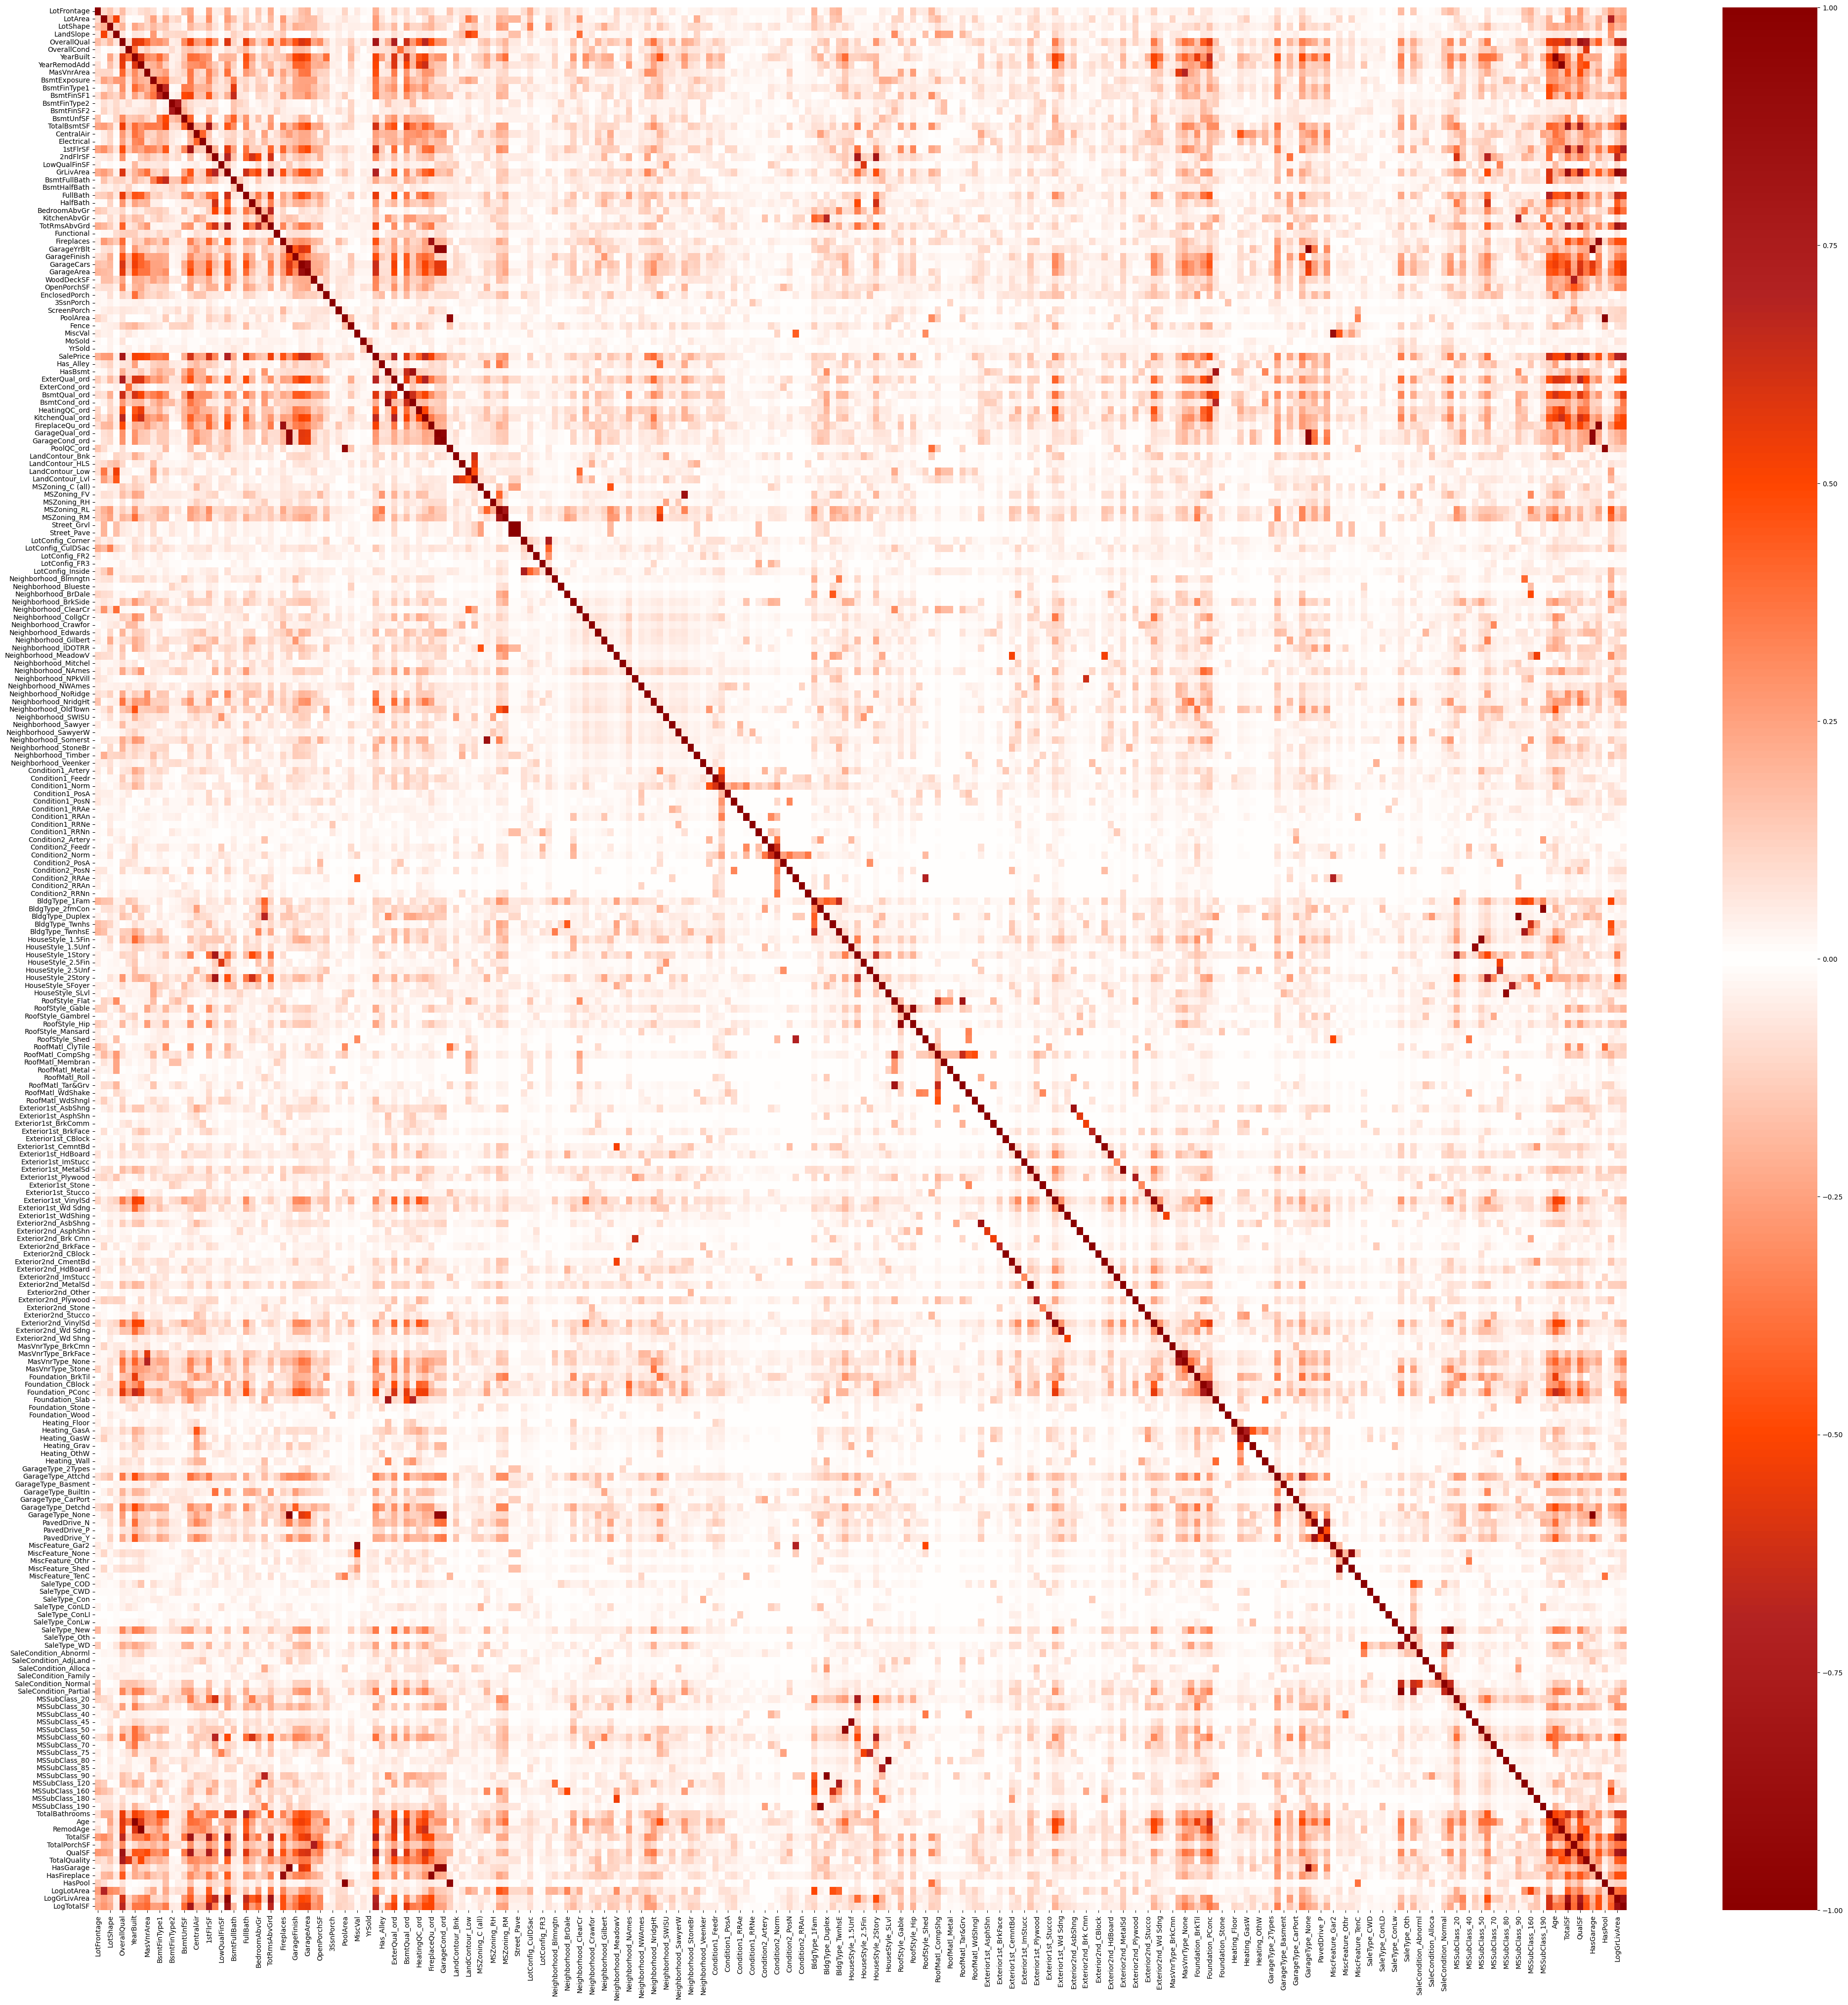

In [112]:
plt.figure(figsize=(50,50))
cor = data[num_feat].corr()

# Custom edits to colormap to show 0 "no correlation" as white, and both correlation extremes as equal colors
colors = ["darkred", "firebrick", "orangered", "white", "orangered", "firebrick", "darkred"]
nodes = [0.0, 0.15, 0.25, 0.5, 0.75, 0.85, 1.0]
double_prawn = mcolors.LinearSegmentedColormap.from_list("double_prawn", list(zip(nodes, colors)))
fit_colors = mcolors.TwoSlopeNorm(vmin=-1.0, vcenter=0, vmax=1.0)

sns.heatmap(cor,cmap=double_prawn, norm=fit_colors)
plt.show()

## Cross-Validation ^^ 

For the cross-validation part, we prepared the data so we could test the models in a fair way instead of training and testing on the exact same rows. We first separated `SalePrice` as the target variable `y`, and the rest of the columns became `X`. After that, we scaled the features with `StandardScaler` so the numeric values were on a more similar scale.

Then we split the data into training and testing parts using `train_test_split`. We used `random_state=1234` so that we would get the same split every time we ran the notebook. The first split kept 20% of the data separate as a holdout set. Then we split the training part again, so we had a smaller training set and a validation/test set for checking model performance while comparing models.

After the split, we made a helper function called `model_eva_sklearn()` to evaluate each model the same way. It predicts on both the training set and the test set, then calculates MAE, MSE, RMSE, and R^2. We used these metrics because one number alone does not always show the full picture. For example, RMSE helps show larger errors more strongly, while R^2 shows how much of the `SalePrice` variation the model explains.

We used this setup to compare the decision tree, the adjusted decision tree, and the random forest model. The main goal was to see if a model was overfitting. If a model did really well on the training data but much worse on the test data, that meant it probably memorized the training data too much instead of learning a pattern that works on new houses.

In [113]:
# Axis Prep
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import time
from tabulate import tabulate
import numpy as np

# Set 'SalePrice' as y
y = np.log(data["SalePrice"]) if "SalePrice" in data.columns else None
X = data.drop(columns=["SalePrice"]) if "SalePrice" in data.columns else data.copy()

# y = data['SalePrice'] if 'SalePrice' in data.columns else None
# X = data.drop(columns=['SalePrice']) if 'SalePrice' in data.columns else data.copy()


if y is not None:
    # Impute missing values (if any)
    imputer = SimpleImputer(strategy='most_frequent')
    X_imputed = imputer.fit_transform(X)
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)
    # Train/test split
    X_train_hierarchical, X_test_hierarchical, y_train_hierarchical, y_test_hierarchical = train_test_split(X_scaled, y.values, test_size=0.2, random_state=1234)

    X_total = X_train_hierarchical
    y_total = y_train_hierarchical

    X_train, X_test, y_train, y_test = train_test_split(X_total, y_total, test_size=0.2, random_state=1234)

In [114]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def model_eva_sklearn(XTrain, XTest, yTrain, yTest, model):
    yTrain_pred = model.predict(XTrain)
    yTest_pred = model.predict(XTest)

    MAE_train = mean_absolute_error(yTrain, yTrain_pred)
    MSE_train = mean_squared_error(yTrain, yTrain_pred)
    RMSE_train = np.sqrt(MSE_train)
    R2_train = r2_score(yTrain, yTrain_pred)

    MAE_test = mean_absolute_error(yTest, yTest_pred)
    MSE_test = mean_squared_error(yTest, yTest_pred)
    RMSE_test = np.sqrt(MSE_test)
    R2_test = r2_score(yTest, yTest_pred)

    return MAE_train, MSE_train, RMSE_train, R2_train, MAE_test, MSE_test, RMSE_test, R2_test

## Models

For the modeling part, we tested a few tree-based regression models to predict `SalePrice`. We started with a basic decision tree first. This model got perfect results on the training data, with training MAE, MSE, and RMSE all equal to 0 and training R^2 equal to 1. But on the test set it did much worse, with a test MAE around 27716, test RMSE around 41269, and test R^2 around 0.735. This showed that the first decision tree was overfitting because it basically memorized the training data.

After that, we tried another decision tree with some limits added, like `max_depth`, `min_samples_split`, and `min_samples_leaf`. This helped reduce overfitting. The training score was not perfect anymore, but the test results improved. The regular decision tree had a test MAE around 22308, test RMSE around 31105, and test R^2 around 0.849. This was better than the overfit tree because it performed better on data it did not train on.

The last model we tested was a random forest with 200 trees. This model performed the best on the validation/test split. It had a test MAE around 14036, test RMSE around 19938, and test R^2 around 0.938. This means the random forest explained more of the variation in house prices and made smaller errors compared to the decision tree models.

Based on these results, the random forest was our best model. After choosing it, we trained a final random forest model on the larger training set and tested it on the holdout data that was not used during model comparison. On that final holdout set, the random forest got MAE around 16920, RMSE around 26413, and R^2 around 0.873. The final score was lower than the validation score, but it still showed that the random forest was the strongest model overall for our project.

In [115]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tabulate import tabulate
import numpy as np

# decision tree model with no hyperparameters to show overfitting
dt_model_overfit = DecisionTreeRegressor(
    random_state=1234
)

# train
dt_model_overfit.fit(X_train, y_train)

# evaluate
MAE_train_dt_overfit, MSE_train_dt_overfit, RMSE_train_dt_overfit, R2_train_dt_overfit, \
MAE_test_dt_overfit, MSE_test_dt_overfit, RMSE_test_dt_overfit, R2_test_dt_overfit = model_eva_sklearn(
    X_train, X_test, y_train, y_test, dt_model_overfit
)

results = []

results.append([
    "DecisionTree Overfit",
    MAE_train_dt_overfit, MSE_train_dt_overfit, RMSE_train_dt_overfit, R2_train_dt_overfit,
    MAE_test_dt_overfit, MSE_test_dt_overfit, RMSE_test_dt_overfit, R2_test_dt_overfit
])

print(tabulate(
    results,
    headers=[
        "Model", "Training MAE", "Training MSE", "Training RMSE", "Training R^2",
        "Test MAE", "Test MSE", "Test RMSE", "Test R^2"
    ],
    tablefmt="grid"
))

+----------------------+----------------+----------------+-----------------+----------------+------------+------------+-------------+------------+
| Model                |   Training MAE |   Training MSE |   Training RMSE |   Training R^2 |   Test MAE |   Test MSE |   Test RMSE |   Test R^2 |
+======================+================+================+=================+================+============+============+=============+============+
| DecisionTree Overfit |              0 |              0 |               0 |              1 |   0.134137 |   0.033467 |     0.18294 |   0.792393 |
+----------------------+----------------+----------------+-----------------+----------------+------------+------------+-------------+------------+


In [116]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tabulate import tabulate
import numpy as np

# decision tree model with hyperparameters to prevent overfitting
dt_model = DecisionTreeRegressor(
    max_depth=40, 
    min_samples_split=20, 
    min_samples_leaf=10,
    random_state=1234
)

# train
dt_model.fit(X_train, y_train)

# evaluate
MAE_train_dt, MSE_train_dt, RMSE_train_dt, R2_train_dt, \
MAE_test_dt, MSE_test_dt, RMSE_test_dt, R2_test_dt = model_eva_sklearn(
    X_train, X_test, y_train, y_test, dt_model
)



results.append([
    "DecisionTree",
    MAE_train_dt, MSE_train_dt, RMSE_train_dt, R2_train_dt,
    MAE_test_dt, MSE_test_dt, RMSE_test_dt, R2_test_dt
])

print(tabulate(
    results,
    headers=[
        "Model", "Training MAE", "Training MSE", "Training RMSE", "Training R^2",
        "Test MAE", "Test MSE", "Test RMSE", "Test R^2"
    ],
    tablefmt="grid"
))

+----------------------+----------------+----------------+-----------------+----------------+------------+------------+-------------+------------+
| Model                |   Training MAE |   Training MSE |   Training RMSE |   Training R^2 |   Test MAE |   Test MSE |   Test RMSE |   Test R^2 |
+======================+================+================+=================+================+============+============+=============+============+
| DecisionTree Overfit |      0         |      0         |        0        |       1        |   0.134137 |  0.033467  |    0.18294  |   0.792393 |
+----------------------+----------------+----------------+-----------------+----------------+------------+------------+-------------+------------+
| DecisionTree         |      0.0854077 |      0.0149183 |        0.122141 |       0.904001 |   0.124264 |  0.0283212 |    0.168289 |   0.824314 |
+----------------------+----------------+----------------+-----------------+----------------+------------+------------

In [117]:
# #search for best hyperparameters for random forest using randomized search
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# from sklearn.model_selection import RandomizedSearchCV
# from tabulate import tabulate
# import numpy as np
# import pandas as pd


# rf_base = RandomForestRegressor(
#     random_state=1234,
#     n_jobs=1,
# )

# param_distributions = {
#     "n_estimators": [200, 300, 500, 700],
#     "max_depth": [None, 10, 20, 30, 40],
#     "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
#     "min_samples_split": [2, 5, 10, 15],
#     "min_samples_leaf": [1, 2, 4],
#     "bootstrap": [True],
#     "max_samples": [None, 0.8, 0.9],
# }

# random_search = RandomizedSearchCV(
#     estimator=rf_base,
#     param_distributions=param_distributions,
#     n_iter=20,
#     scoring="neg_mean_squared_error",
#     cv=4,
#     random_state=1234,
#     n_jobs=1,
#     verbose=1,
# )

# random_search.fit(X_train, y_train)

# best_rf_params = random_search.best_params_
# best_cv_rmse = np.sqrt(-random_search.best_score_)

# print("Best random forest parameters:")
# print(best_rf_params)
# print(f"Best 4-fold CV RMSE on log(SalePrice): {best_cv_rmse:.5f}")

# # Best random forest parameters:
# # {'n_estimators': 700, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_samples': None, 'max_features': 'sqrt', 'max_depth': 10, 'bootstrap': True}
# # Best 4-fold CV RMSE on log(SalePrice): 0.14042

In [118]:
# #search for best hyperparameters for random forest using randomized search
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from tabulate import tabulate
import numpy as np
import pandas as pd
rf_model = RandomForestRegressor(
    n_estimators=700,
    min_samples_split=2,
    min_samples_leaf=1,
    max_samples=None,
    max_features="sqrt",
    max_depth=10,
    bootstrap=True,
    random_state=1234,
    n_jobs=-1,
)
# rf_model = random_search.best_estimator_
rf_model.fit(X_train, y_train)
# evaluate
MAE_train_rf, MSE_train_rf, RMSE_train_rf, R2_train_rf, \
MAE_test_rf, MSE_test_rf, RMSE_test_rf, R2_test_rf = model_eva_sklearn(
    X_train, X_test, y_train, y_test, rf_model
)

results.append([
    "RandomForest Tuned",
    MAE_train_rf, MSE_train_rf, RMSE_train_rf, R2_train_rf,
    MAE_test_rf, MSE_test_rf, RMSE_test_rf, R2_test_rf
])

print(tabulate(
    results,
    headers=[
        "Model", "Training MAE", "Training MSE", "Training RMSE", "Training R^2",
        "Test MAE", "Test MSE", "Test RMSE", "Test R^2"
    ],
    tablefmt="grid"
))

+----------------------+----------------+----------------+-----------------+----------------+------------+------------+-------------+------------+
| Model                |   Training MAE |   Training MSE |   Training RMSE |   Training R^2 |   Test MAE |   Test MSE |   Test RMSE |   Test R^2 |
+======================+================+================+=================+================+============+============+=============+============+
| DecisionTree Overfit |      0         |     0          |       0         |       1        |  0.134137  |  0.033467  |    0.18294  |   0.792393 |
+----------------------+----------------+----------------+-----------------+----------------+------------+------------+-------------+------------+
| DecisionTree         |      0.0854077 |     0.0149183  |       0.122141  |       0.904001 |  0.124264  |  0.0283212 |    0.168289 |   0.824314 |
+----------------------+----------------+----------------+-----------------+----------------+------------+------------

After choosing our best model, we tested it on data it had not seen before.

In [119]:
# Train the final random forest on all training data from the first split
# using the best parameters found by RandomizedSearchCV.
final_rf_model = rf_model

final_rf_model.fit(X_total, y_total)

rf_model = final_rf_model

final_pred = rf_model.predict(X_test_hierarchical)

final_mae = mean_absolute_error(y_test_hierarchical, final_pred)
final_mse = mean_squared_error(y_test_hierarchical, final_pred)
final_rmse = np.sqrt(final_mse)
final_r2 = r2_score(y_test_hierarchical, final_pred)

print("Final MAE:", final_mae)
print("Final MSE:", final_mse)
print("Final RMSE:", final_rmse)
print("Final R^2:", final_r2)

Final MAE: 0.097035209989477
Final MSE: 0.024483228344659845
Final RMSE: 0.15647117416527506
Final R^2: 0.8563747785351661


## Visualization 

For the visualization part, we used graphs to understand the data better and also to check how our final model was doing. First, we plotted the distribution of `SalePrice` with a histogram and KDE line. This helped us see how house prices were spread out and showed that most houses were in the lower and middle price range, while fewer houses had very high prices.

We also made scatter plots between `SalePrice` and the numeric features. The goal was to see which features had a strong relationship with price. For example, `TotalSF` had a positive relationship with `SalePrice`, which makes sense because bigger houses usually sell for more. `Age` had more of a negative relationship, meaning older houses often had lower prices. We also included a feature like `Foundation_Wood` to show an example where there was not really a clear relationship with `SalePrice`.

After building the random forest model, we made a predicted vs actual price plot. This was useful because if the model was doing well, the points should be close to the red diagonal line. We also plotted the residuals, which are the prediction errors. That helped us see how far off the model usually was and whether the errors were mostly centered around zero.

Finally, we plotted the top 20 random forest feature importances. This showed which features the model relied on the most when making predictions. We also compared actual and predicted prices against important features like `TotalSF` and `OverallQual`, so we could visually check if the model was following the same general trends as the real data. Overall, the visualizations helped us explain both the dataset patterns and the performance of the random forest model.

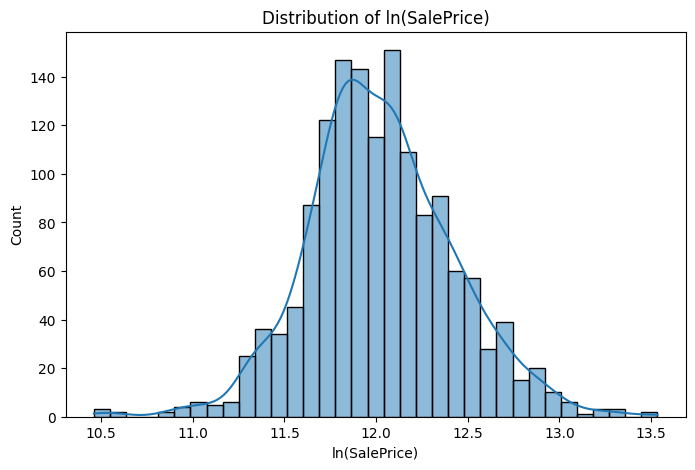

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(np.log(data["SalePrice"]), kde=True)
plt.title("Distribution of ln(SalePrice)")
plt.xlabel("ln(SalePrice)")
plt.ylabel("Count")
plt.show()


In [121]:
# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd

# # Create the log target first. The original column is SalePrice, not SalesPrice.
# data["LogSalePrice"] = np.log(data["SalePrice"])

# # Correlation only works on numeric columns. This includes one-hot encoded columns too.
# numeric_data = data.select_dtypes(include=[np.number])

# # Correlation of every numeric feature with log sale price.
# corr_with_log_price = (
#     numeric_data
#     .corr()["LogSalePrice"]
#     .drop(labels=["LogSalePrice", "SalePrice"], errors="ignore")
#     .dropna()
#     .sort_values(key=lambda s: s.abs(), ascending=False)
# )

# plot_corr = corr_with_log_price.sort_values()
# colors = ["steelblue" if value < 0 else "firebrick" for value in plot_corr.values]

# plt.figure(figsize=(10, max(8, 0.22 * len(plot_corr))))
# plt.barh(plot_corr.index, plot_corr.values, color=colors)
# plt.axvline(0, color="black", linewidth=1)
# plt.title("Correlation of All Numeric Features with LogSalePrice")
# plt.xlabel("Correlation with log(SalePrice)")
# plt.ylabel("Feature")
# plt.tight_layout()
# plt.show()

# corr_with_log_price.to_frame("Correlation_with_LogSalePrice")

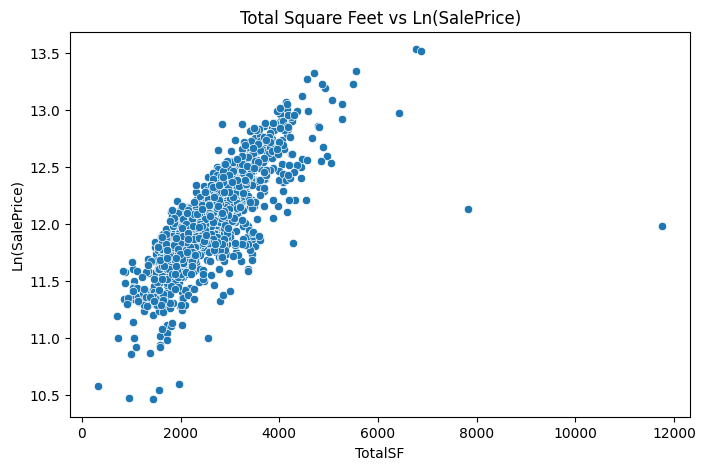

In [122]:
#positively correlated feature with SalePrice is TotalSF
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x="TotalSF", y=np.log(data["SalePrice"]))
plt.title("Total Square Feet vs Ln(SalePrice)")
plt.xlabel("TotalSF")
plt.ylabel("Ln(SalePrice)")
plt.show()


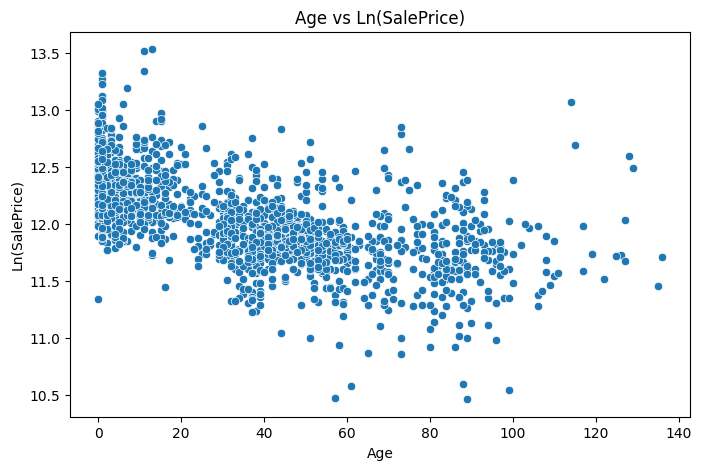

In [123]:
#negatively correlated feature with SalePrice is Age
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x="Age", y=np.log(data["SalePrice"]))
plt.title("Age vs Ln(SalePrice)")
plt.xlabel("Age")
plt.ylabel("Ln(SalePrice)")
plt.show()


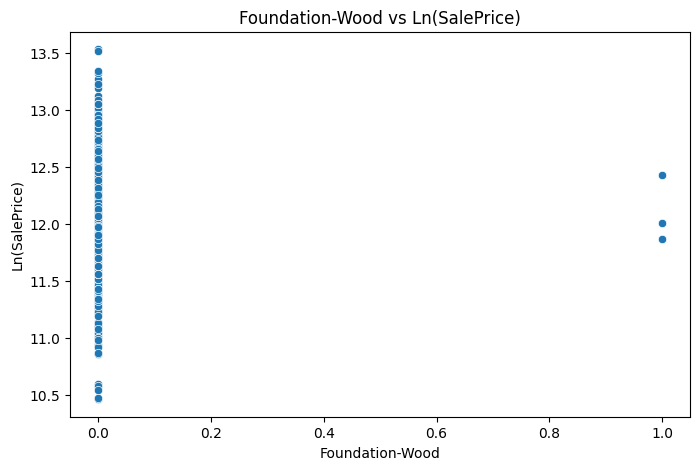

In [124]:
#no correlated feature with SalePrice is Age
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x="Foundation_Wood", y=np.log(data["SalePrice"]))
plt.title("Foundation-Wood vs Ln(SalePrice)")
plt.xlabel("Foundation-Wood")
plt.ylabel("Ln(SalePrice)")
plt.show()


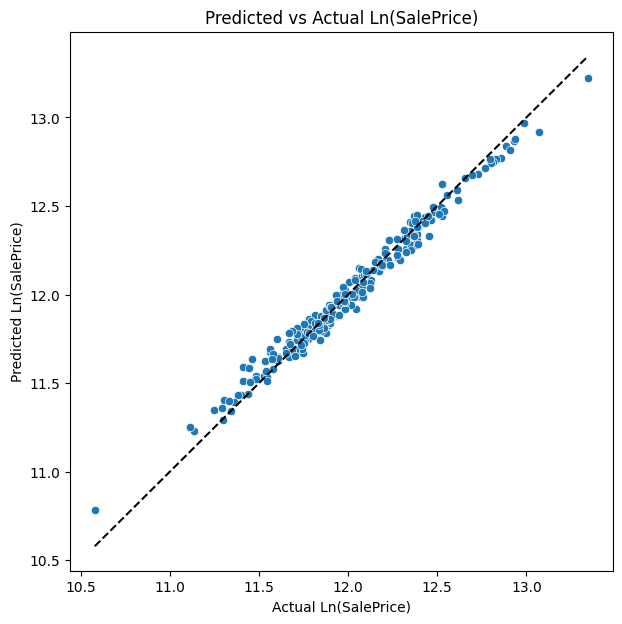

In [125]:
y_pred_log = rf_model.predict(X_test)

y_test_price = np.expm1(y_test)
y_pred_price = np.expm1(y_pred_log)

plt.figure(figsize=(7, 7))
sns.scatterplot(x=np.log(y_test_price), y=np.log(y_pred_price))

min_price = min(np.log(y_test_price).min(), np.log(y_pred_price).min())
max_price = max(np.log(y_test_price).max(), np.log(y_pred_price).max())
plt.plot([min_price, max_price], [min_price, max_price], color="black", linestyle="--")

plt.title("Predicted vs Actual Ln(SalePrice)")
plt.xlabel("Actual Ln(SalePrice)")
plt.ylabel("Predicted Ln(SalePrice)")
plt.show()



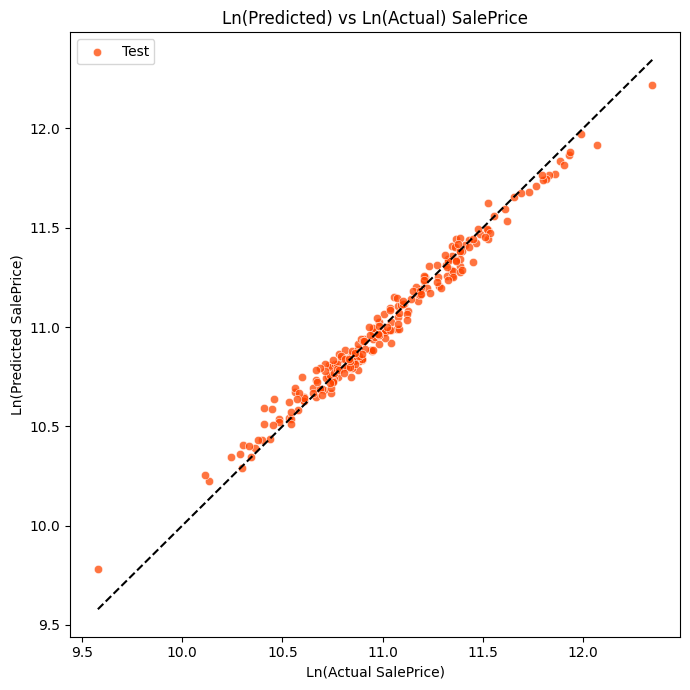

In [126]:
# Predicted vs actual SalePrice for both training and test data
# train_pred_log = rf_model.predict(X_train)
test_pred_log = rf_model.predict(X_test)

# train_actual_price = np.expm1(np.log(y_train))
# train_pred_price = np.expm1(np.log(train_pred_log))
test_actual_price = np.expm1(np.log(y_test))
test_pred_price = np.expm1(np.log(test_pred_log))

plt.figure(figsize=(7, 7))

# sns.scatterplot(
#     x=train_actual_price,
#     y=train_pred_price,
#     label="Train",
#     alpha=0.45,
#     color="steelblue",
# )

sns.scatterplot(
    x=test_actual_price,
    y=test_pred_price,
    label="Test",
    alpha=0.75,
    color="orangered",
)

min_price = min(
    # train_actual_price.min(),
    # train_pred_price.min(),
    test_actual_price.min(),
    test_pred_price.min(),
)
max_price = max(
    # train_actual_price.max(),
    # train_pred_price.max(),
    test_actual_price.max(),
    test_pred_price.max(),
)

plt.plot([min_price, max_price], [min_price, max_price], color="black", linestyle="--")
plt.title("Ln(Predicted) vs Ln(Actual) SalePrice")
plt.xlabel("Ln(Actual SalePrice)")
plt.ylabel("Ln(Predicted SalePrice)")
plt.legend()
plt.tight_layout()
plt.show()

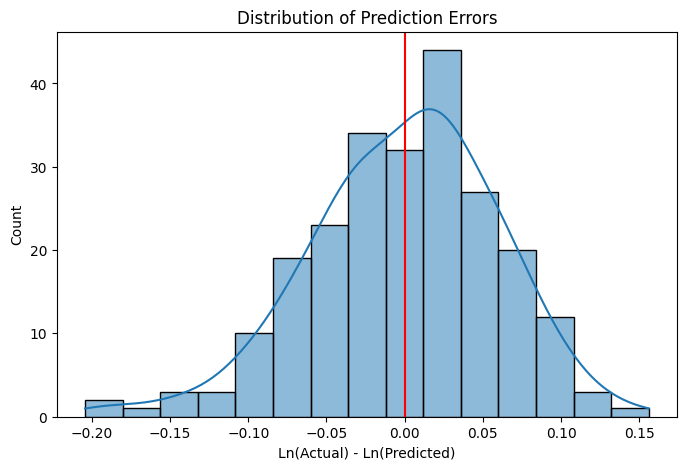

In [127]:
residuals = np.log(y_test_price) - np.log(y_pred_price)

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True)
plt.axvline(0, color="red")
plt.title("Distribution of Prediction Errors")
plt.xlabel("Ln(Actual) - Ln(Predicted)")
plt.ylabel("Count")
plt.show()


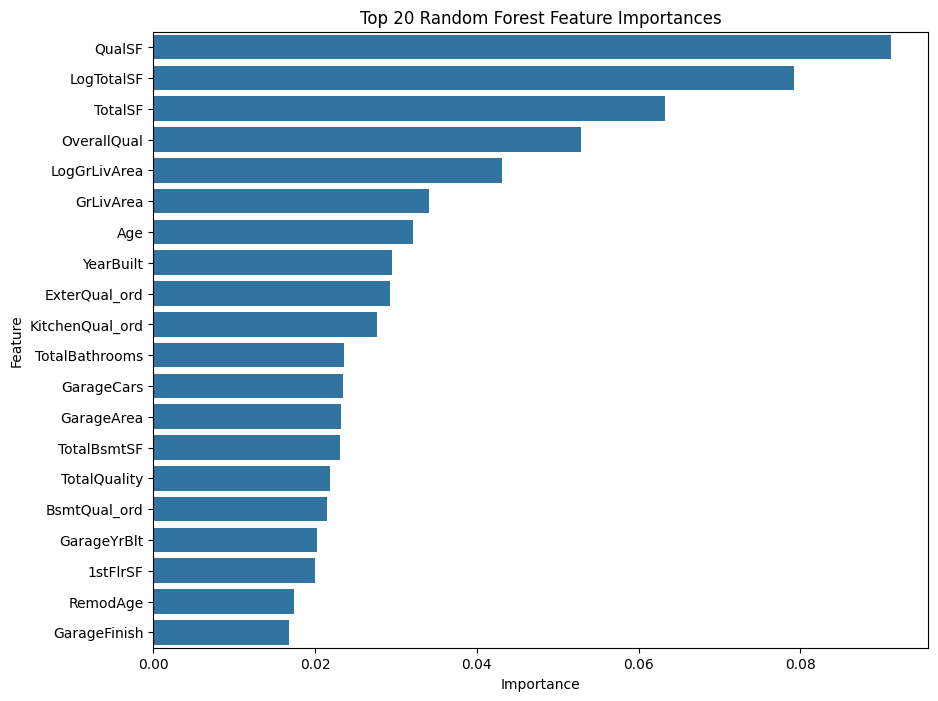

In [128]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importance.head(20),
    x="Importance",
    y="Feature"
)
plt.title("Top 20 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


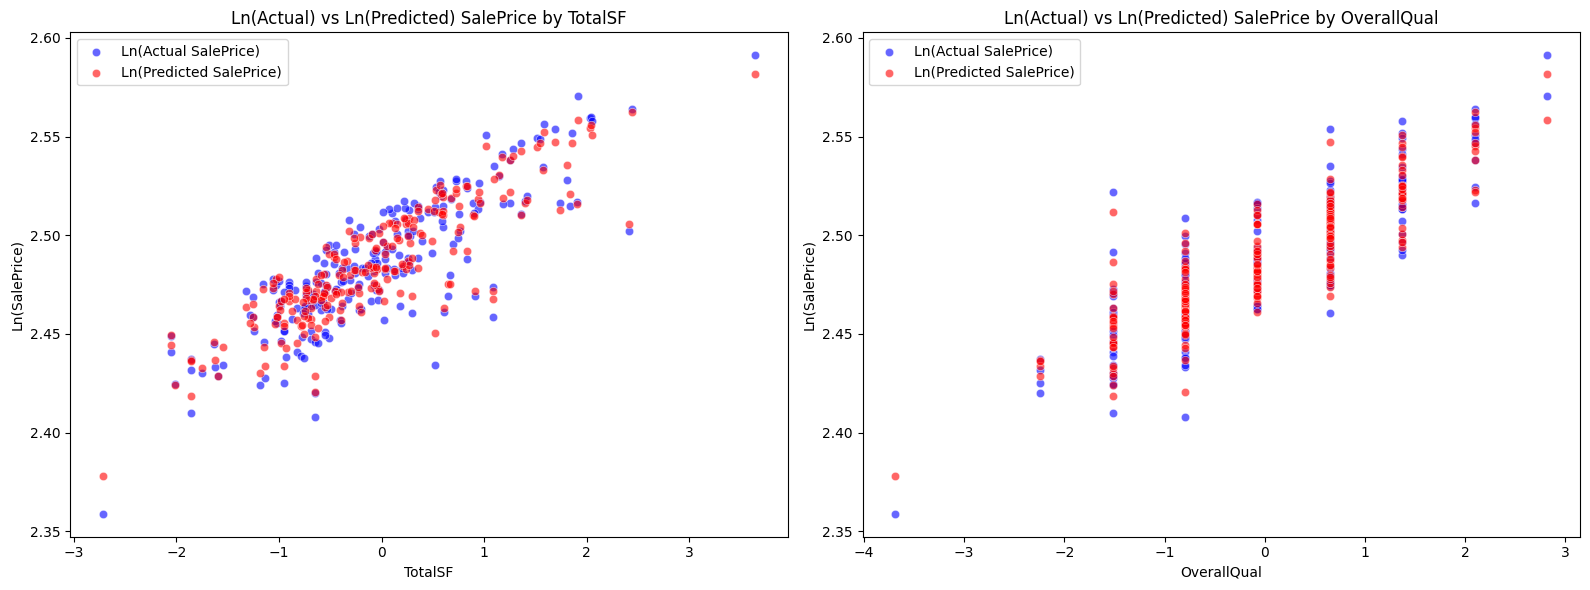

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Predict prices for your validation/test split
y_pred = rf_model.predict(X_test)

# Put actual and predicted values together with the features
plot_data = X_test.copy()

# If X_test is a numpy array because of imputer/scaler, rebuild it as a DataFrame
if not isinstance(plot_data, pd.DataFrame):
    plot_data = pd.DataFrame(X_test, columns=X.columns)

plot_data["Actual_SalePrice"] = np.log(y_test)
plot_data["Predicted_SalePrice"] = np.log(y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# TotalSF plot
sns.scatterplot(
    data=plot_data,
    x="TotalSF",
    y="Actual_SalePrice",
    color="blue",
    label="Ln(Actual SalePrice)",
    alpha=0.6,
    ax=axes[0]
)

sns.scatterplot(
    data=plot_data,
    x="TotalSF",
    y="Predicted_SalePrice",
    color="red",
    label="Ln(Predicted SalePrice)",
    alpha=0.6,
    ax=axes[0]
)

axes[0].set_title("Ln(Actual) vs Ln(Predicted) SalePrice by TotalSF")
axes[0].set_xlabel("TotalSF")
axes[0].set_ylabel("Ln(SalePrice)")
axes[0].legend()

# OverallQual plot
sns.scatterplot(
    data=plot_data,
    x="OverallQual",
    y="Actual_SalePrice",
    color="blue",
    label="Ln(Actual SalePrice)",
    alpha=0.6,
    ax=axes[1]
)

sns.scatterplot(
    data=plot_data,
    x="OverallQual",
    y="Predicted_SalePrice",
    color="red",
    label="Ln(Predicted SalePrice)",
    alpha=0.6,
    ax=axes[1]
)

axes[1].set_title("Ln(Actual) vs Ln(Predicted) SalePrice by OverallQual")
axes[1].set_xlabel("OverallQual")
axes[1].set_ylabel("Ln(SalePrice)")
axes[1].legend()

plt.tight_layout()
plt.show()


In [130]:
# numeric_data = data.select_dtypes(include=["int64", "float64"])

# # plt.figure(figsize=(14, 10))
# # corr = numeric_data.corr()
# # sns.heatmap(corr, cmap="coolwarm", center=0)
# # plt.title("Correlation Heatmap")
# # plt.show()

# corr_with_price = numeric_data.corr()["SalePrice"].sort_values(ascending=False)

# plt.figure(figsize=(10, 40))
# corr_with_price.plot(kind="barh")
# plt.title("Top Features Correlated with SalePrice")
# plt.xlabel("Correlation")
# plt.gca().invert_yaxis()
# plt.show()


## Kaggle Submisssion

In this part, we prepared the Kaggle submission file. We used our final random forest model to predict `SalePrice` for the test dataset, then saved the results with the house `Id` and predicted `SalePrice` in a CSV file that can be submitted to Kaggle.

In [131]:
from pathlib import Path

import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


TEST_PATH = "https://raw.githubusercontent.com/dana-fatemeh/Final-ML-Project/main/Data/test.csv"

SUBMISSION_PATH = "submission.csv"


# train_raw = pd.read_csv(TRAIN_PATH)
test_raw = pd.read_csv(TEST_PATH)
test_ids = test_raw["Id"]

train_data = data.copy()
test_data = feature_engineer(test_raw)

y = np.log(train_data["SalePrice"])

X = train_data.drop(columns=["SalePrice"])
test_data = test_data.reindex(columns=X.columns, fill_value=0)

imputer = SimpleImputer(strategy="most_frequent")
X_imputed = imputer.fit_transform(X)
test_imputed = imputer.transform(test_data)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)
test_scaled = scaler.transform(test_imputed)

# Use tuned parameters if the RandomizedSearchCV cell has already been run.
submission_rf_params = globals().get(
    "best_rf_params",
    {
        "n_estimators": 500,
        "max_features": "sqrt",
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "max_depth": None,
        "bootstrap": True,
        "max_samples": None,
    },
)

rf_model = RandomForestRegressor(
    **submission_rf_params,
    random_state=1234,
    n_jobs=1,
)
rf_model.fit(X_scaled, y)

log_sale_price_predictions = rf_model.predict(test_scaled)
sale_price_predictions = np.expm1(log_sale_price_predictions)

submission = pd.DataFrame(
    {
        "Id": test_ids,
        "SalePrice": sale_price_predictions,
    }
)
submission.to_csv(SUBMISSION_PATH, index=False)
print(f"Saved {SUBMISSION_PATH} with {len(submission)} rows.")


# from google.colab import files

# files.download("submission.csv")

Saved submission.csv with 1459 rows.
